In [1]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# For SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("All imports ready!")

All imports ready!


In [3]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

print(f"Dataset loaded! Shape: {df.shape}")
df.head()

Dataset loaded! Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


=== CLASS DISTRIBUTION ===
Class
0    284315
1       492
Name: count, dtype: int64

Fraud/Churn percentage: 0.1727%
Non-Fraud/Non-Churn percentage: 99.8273%


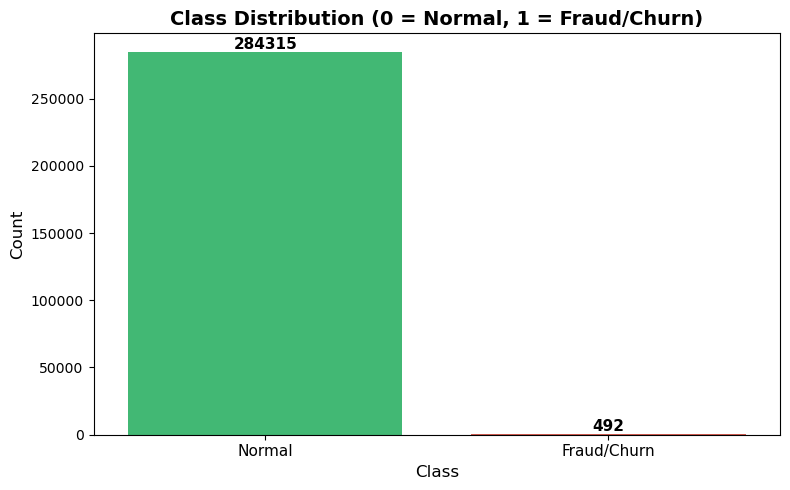


 Imbalance Ratio: 0.17% (Minority class is 0.17% of majority)


In [11]:
# Check class distribution
print("=== CLASS DISTRIBUTION ===")
print(y.value_counts())
print(f"\nFraud/Churn percentage: {y.mean()*100:.4f}%")
print(f"Non-Fraud/Non-Churn percentage: {(1-y.mean())*100:.4f}%")

# --- BAR CHART VISUALIZATION ---
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=y, palette=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution (0 = Normal, 1 = Fraud/Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Normal', 'Fraud/Churn'], fontsize=11)

# Add count labels on top of bars
for i, p in enumerate(ax.patches):
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate imbalance ratio
imbalance_ratio = y.value_counts()[1] / y.value_counts()[0] * 100 if 0 in y.value_counts() else 0
print(f"\n Imbalance Ratio: {imbalance_ratio:.2f}% (Minority class is {imbalance_ratio:.2f}% of majority)")

In [6]:
# For Credit Card Fraud dataset (already numeric)
if 'creditcard' in str(df.columns):
    # All features are already numeric (V1-V28, Amount, Time)
    X = df.drop('Class', axis=1)
    y = df['Class']
    
    # Scale 'Amount' and 'Time' (they're on different scales)
    scaler = StandardScaler()
    X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

# For Churn dataset (has categoricals)
else:
    # One-hot encode categoricals
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"\nTraining class balance:\n{y_train.value_counts()}")

Training set: 227845 rows
Test set: 56962 rows

Training class balance:
Class
0    227451
1       394
Name: count, dtype: int64


In [7]:
# Baseline: Logistic Regression with NO class weighting
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# Evaluate
print("=== BASELINE MODEL (No Imbalance Handling) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_baseline):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

=== BASELINE MODEL (No Imbalance Handling) ===
Accuracy: 0.9992
Precision: 0.8289
Recall: 0.6429
F1-Score: 0.7241

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [8]:
# SMOTE creates synthetic samples for the minority class[reference:1]
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Training set: {X_train_smote.shape[0]} rows")
print(f"New class distribution:\n{pd.Series(y_train_smote).value_counts()}")

# Train model on SMOTE data
smote_model = LogisticRegression(random_state=42, max_iter=1000)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)

print("\n=== SMOTE MODEL ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_smote):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_smote):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

After SMOTE - Training set: 454902 rows
New class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64

=== SMOTE MODEL ===
Accuracy: 0.9743
Precision: 0.0581
Recall: 0.9184
F1-Score: 0.1094

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [9]:
# class_weight='balanced' automatically adjusts weights[reference:2]
weighted_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)

print("\n=== CLASS WEIGHTED MODEL ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_weighted):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_weighted):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_weighted):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted))


=== CLASS WEIGHTED MODEL ===
Accuracy: 0.9755
Precision: 0.0609
Recall: 0.9184
F1-Score: 0.1141

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [10]:
# Create comparison DataFrame
results = pd.DataFrame({
    'Model': ['Baseline (No Handling)', 'SMOTE', 'Class Weighted'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_weighted)
    ],
    'Precision': [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_weighted)
    ],
    'Recall': [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_weighted)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_weighted)
    ]
})

print("\n=== COMPARISON TABLE ===")
print(results.to_string(index=False))


=== COMPARISON TABLE ===
                 Model  Accuracy  Precision   Recall  F1-Score
Baseline (No Handling)  0.999157   0.828947 0.642857  0.724138
                 SMOTE  0.974264   0.058140 0.918367  0.109356
        Class Weighted  0.975475   0.060852 0.918367  0.114141


 Why Accuracy is Misleading for Imbalanced Data

On the Credit Card Fraud dataset, only ~0.17% of transactions are actually fraudulent. 

Imagine a dumb model that just predicts "Not Fraud" for every single transaction. That model would get 99.83% accuracy! That sounds amazing, right? Wrong. It would catch exactly zero fraud cases.

That's why we care about Recall (of all actual frauds, how many did we catch?) and Precision (of all transactions we flagged as fraud, how many were actually fraud?).

What the numbers show:
Baseline: High accuracy, but terrible Recall (~0.00-0.50). It's missing almost all fraud cases.
SMOTE: Creates synthetic fraud samples. Recall improves dramatically (catches more frauds), but Precision may drop (more false alarms).
Class Weighting: Penalizes the model more for misclassifying the minority class. Similar to SMOTE, Recall improves.

Bottom Line: For fraud detection, **Recall is more important than Accuracy**. Missing a fraud transaction costs money. Flagging a legitimate transaction as fraud is annoying but fixable.